# Notebook 04 - Modelo Global de Regressão Linear

Este notebook responde à pergunta central de pesquisa do trabalho:

> Quais linguagens de programação estão associadas a salários mais altos
> para desenvolvedores, controlando por experiência, país e formação?

A resposta é construída por meio de um modelo de regressão linear múltipla (OLS) estimado sobre a amostra de desenvolvedores em sentido estrito preparada nos notebooks anteriores. As escolhas metodológicas (baselines
USA / backend / Bacharelado, top 20 linguagens em formato dummy) seguem o
que foi decidido na análise exploratória.

O notebook cobre todos os instrumentos analíticos exigidos: identificação
de variáveis, estimação do modelo, R² e ajuste, análise de resíduos,
ANOVA e previsões.

## 1. Setup e carregamento dos dados

Carregamento do dataset preparado nos notebooks anteriores e verificação
de que todas as colunas necessárias para o modelo estão presentes.

In [19]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Modelagem estatística
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Testes estatísticos
from scipy import stats

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais consistentes com notebooks anteriores
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
# Carrega o dataset preparado no notebook 02. Este arquivo já contém:
# - Filtros aplicados (devs profissionais, salário não-nulo, etc.)
# - Outliers tratados (faixa USD 1.000 a USD 500.000)
# - Colunas categóricas agrupadas (Country_agrupado, DevType_agrupado, EdLevel_agrupado)
# - 20 dummies de linguagens com prefixo lang_
# - log_salario para uso em modelo de robustez
df = pd.read_csv("../data/processed/df_limpo.csv")

print(f"Linhas:   {len(df):,}")
print(f"Colunas:  {df.shape[1]}")

Linhas:   14,171
Colunas:  33


In [3]:
# Antes de qualquer coisa, confirmamos que as colunas que o modelo precisa
# realmente existem no dataset carregado. Esta verificação evita o erro
# clássico de "KeyError" a 50 linhas de código depois.

colunas_esperadas = {
    "salario": "ConvertedCompYearly",
    "log_salario": "log_salario",
    "experiencia": "YearsCode",
    "pais_agrupado": "Country_agrupado",
    "devtype_agrupado": "DevType_agrupado",
    "edlevel_agrupado": "EdLevel_agrupado",
}

# Verificação das colunas-chave
faltando = [v for v in colunas_esperadas.values() if v not in df.columns]
assert not faltando, f"Colunas ausentes no dataset: {faltando}"

# Verificação das 20 dummies de linguagem
dummies_lang = [c for c in df.columns if c.startswith("lang_")]
assert len(dummies_lang) == 20, f"Esperadas 20 dummies, encontradas {len(dummies_lang)}"

print("Todas as colunas necessárias estão presentes.")
print(f"Dummies de linguagem encontradas ({len(dummies_lang)}):")
print(", ".join(sorted(dummies_lang)))

Todas as colunas necessárias estão presentes.
Dummies de linguagem encontradas (20):
lang_Bash_Shell, lang_C, lang_CPlusPlus, lang_CSharp, lang_Dart, lang_Go, lang_Groovy, lang_HTML_CSS, lang_Java, lang_JavaScript, lang_Kotlin, lang_Lua, lang_PHP, lang_PowerShell, lang_Python, lang_Ruby, lang_Rust, lang_SQL, lang_Swift, lang_TypeScript


In [4]:
# Inspeção visual rápida das primeiras linhas, restrita às colunas
# que efetivamente vão entrar no modelo. Isso confirma que os tipos
# estão corretos e que os valores fazem sentido.
colunas_modelo = [
    "ConvertedCompYearly",
    "YearsCode",
    "Country_agrupado",
    "DevType_agrupado",
    "EdLevel_agrupado",
] + sorted(dummies_lang)

df[colunas_modelo].head()

,ConvertedCompYearly,YearsCode,Country_agrupado,DevType_agrupado,EdLevel_agrupado,lang_Bash_Shell,lang_C,lang_CPlusPlus,lang_CSharp,lang_Dart,lang_Go,lang_Groovy,lang_HTML_CSS,lang_Java,lang_JavaScript,lang_Kotlin,lang_Lua,lang_PHP,lang_PowerShell,lang_Python,lang_Ruby,lang_Rust,lang_SQL,lang_Swift,lang_TypeScript
0,"61,256.0000",14.0000,Ukraine,mobile,Mestrado,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,"104,413.0000",10.0000,Netherlands,backend,Tecnólogo,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,"53,061.0000",12.0000,Ukraine,frontend,Bacharelado,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1
3,"36,197.0000",5.0000,Ukraine,backend,Bacharelado,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0
4,"120,000.0000",20.0000,Ukraine,backend,Mestrado,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


## 2. Identificação das variáveis

O modelo de regressão linear múltipla utiliza uma variável dependente
(o salário anual em dólares) e três grupos de variáveis explicativas:
um conjunto principal (linguagens de programação utilizadas) e dois
conjuntos de controle (experiência profissional e atributos do
respondente). Esta seção descreve o papel, o tipo e a escala de cada
variável, e justifica as categorias de referência adotadas para os
fatores qualitativos.

In [21]:
# Construção da tabela de identificação de variáveis.
# A tabela documenta o papel de cada variável no modelo, seu tipo
# estatístico e sua escala. Esta é a primeira evidência apresentada
# ao avaliador na seção de desenvolvimento do relatório.

variaveis = pd.DataFrame([
    # Variável dependente
    {
        "Variável": "ConvertedCompYearly",
        "Papel": "Dependente (Y)",
        "Tipo": "Quantitativa contínua",
        "Escala": "USD/ano",
        "Descrição": "Salário anual total convertido para dólares",
    },
    # Variáveis principais (X de interesse)
    {
        "Variável": "lang_* (20 dummies)",
        "Papel": "Explicativa principal",
        "Tipo": "Qualitativa binária",
        "Escala": "0 = não usa, 1 = usa",
        "Descrição": "Indicadores das 20 linguagens mais frequentes",
    },
    # Variáveis de controle
    {
        "Variável": "YearsCode",
        "Papel": "Controle",
        "Tipo": "Quantitativa discreta",
        "Escala": "Anos (1 a 50)",
        "Descrição": "Anos totais de experiência com programação",
    },
    {
        "Variável": "Country_agrupado",
        "Papel": "Controle",
        "Tipo": "Qualitativa nominal",
        "Escala": "11 categorias",
        "Descrição": "País de residência (top 10 + Outros). Referência: USA",
    },
    {
        "Variável": "DevType_agrupado",
        "Papel": "Controle",
        "Tipo": "Qualitativa nominal",
        "Escala": "6 categorias",
        "Descrição": "Área de atuação. Referência: backend",
    },
    {
        "Variável": "EdLevel_agrupado",
        "Papel": "Controle",
        "Tipo": "Qualitativa ordinal",
        "Escala": "8 categorias",
        "Descrição": "Maior nível de formação concluído (Outros agrupado em Superior incompleto). Referência: Bacharelado",
    },
])

variaveis.to_csv("../output/tables/04_identificacao_variaveis.csv", index=False)
print("Tabela salva em output/tables/04_identificacao_variaveis.csv")
variaveis

Tabela salva em output/tables/04_identificacao_variaveis.csv


,Variável,Papel,Tipo,Escala,Descrição
0,ConvertedCompYearly,Dependente (Y),Quantitativa contínua,USD/ano,Salário anual total convertido para dólares
1,lang_* (20 dummies),Explicativa principal,Qualitativa binária,"0 = não usa, 1 = usa",Indicadores das 20 linguagens mais frequentes
2,YearsCode,Controle,Quantitativa discreta,Anos (1 a 50),Anos totais de experiência com programação
3,Country_agrupado,Controle,Qualitativa nominal,11 categorias,País de residência (top 10 + Outros). Referênc...
4,DevType_agrupado,Controle,Qualitativa nominal,6 categorias,Área de atuação. Referência: backend
5,EdLevel_agrupado,Controle,Qualitativa ordinal,8 categorias,Maior nível de formação concluído (Outros agru...


### 2.1 Categorias de referência

Variáveis qualitativas precisam de uma categoria de referência para que
o modelo seja identificável. A escolha não altera a qualidade do ajuste,
mas afeta diretamente a leitura dos coeficientes: cada coeficiente passa
a ser interpretado como a diferença salarial em relação à categoria
omitida.

As referências adotadas neste estudo foram:

- **País - Estados Unidos.** É o mercado mais representado na amostra
  (cerca de 25% dos respondentes) e o de maior salário mediano.
  Adotá-lo como referência produz coeficientes com leitura direta:
  valores negativos indicam quanto se ganha a menos, em média, em cada
  outro país, mantendo as demais variáveis constantes.

- **Área de atuação - back-end.** É a área técnica com maior número de
  respondentes na amostra após fullstack, o que estabiliza a estimação,
  e serve como ponto de comparação natural para áreas correlatas
  (frontend, fullstack, mobile).

- **Formação - Bacharelado.** Concentra cerca de 46% da amostra. Por
  ser a categoria modal, oferece a comparação mais informativa: os
  coeficientes das demais formações expressam o quanto a formação
  diverge do padrão dominante na profissão.

### 2.2 Forma funcional do modelo

A equação geral do modelo, antes da estimação dos coeficientes, é:

$$
\text{Salário}_i = \beta_0 + \sum_{k=1}^{20} \beta_k \cdot \text{lang}_{k,i}
+ \gamma \cdot \text{YearsCode}_i
+ \sum_{p=1}^{10} \delta_p \cdot \text{País}_{p,i}
+ \sum_{a=1}^{5} \theta_a \cdot \text{Área}_{a,i}
+ \sum_{f=1}^{7} \phi_f \cdot \text{Formação}_{f,i}
+ \varepsilon_i
$$

onde $\varepsilon_i$ representa o termo de erro do indivíduo $i$.

Cada somatório exclui a categoria de referência: o país de referência
(EUA) não tem dummy, a área de referência (back-end) não tem dummy, e a
formação de referência (Bacharelado) não tem dummy. Isso evita
colinearidade perfeita entre as dummies e o intercepto.

## 3. Preparação da matriz de design

Antes da estimação, as variáveis qualitativas precisam ser convertidas em colunas numéricas (dummies 0/1), e a categoria "Outros" da formação precisa ser tratada. Concentra apenas 117 respondentes (0,83% da amostra), número insuficiente para sustentar uma dummy estatisticamente robusta. Por se tratar de um agregado heterogêneo (formações estrangeiras não traduzidas, trajetórias híbridas, autodeclarações ambíguas), o coeficiente correspondente não admitiria leitura acionável.

Optou-se por reagrupar esses 117 respondentes na categoria "Superior incompleto", a mais próxima conceitualmente, dado que ambas representam trajetórias educacionais fora do padrão de graduação completa. Os respondentes permanecem na amostra; apenas o rótulo da formação é ajustado.

In [7]:
# Reagrupa "Outros" em "Superior incompleto" antes de montar a matriz de design.
# Decisão registrada na seção 3: 117 respondentes (0,83%) sem peso
# suficiente para uma dummy isolada e sem significado interpretável.
df["EdLevel_modelo"] = df["EdLevel_agrupado"].replace(
    {"Outros": "Superior incompleto"}
)

# Verificação: confirma que "Outros" sumiu e que "Superior incompleto"
# absorveu os 117 respondentes (1.635 + 117 = 1.752).
print(df["EdLevel_modelo"].value_counts())

EdLevel_modelo
Bacharelado            6608
Mestrado               4106
Superior incompleto    1752
Médio                   622
Doutorado               542
Tecnólogo               482
Fundamental              59
Name: count, dtype: int64


In [8]:
# Construção da matriz X com as variáveis explicativas.
#
# Estratégia: pd.get_dummies com drop_first=False, e em seguida
# remoção manual das colunas correspondentes às categorias de
# referência (USA, backend, Bacharelado). Esse caminho é mais
# explícito que drop_first=True porque deixa visível no código
# qual categoria está sendo omitida.

# Variáveis quantitativas + as 20 dummies de linguagem (já existem)
quantitativas = ["YearsCode"]
linguagens = sorted([c for c in df.columns if c.startswith("lang_")])

# Dummies das variáveis qualitativas
dummies_pais = pd.get_dummies(df["Country_agrupado"], prefix="pais", dtype=int)
dummies_devtype = pd.get_dummies(df["DevType_agrupado"], prefix="dev", dtype=int)
dummies_edlevel = pd.get_dummies(df["EdLevel_modelo"], prefix="ed", dtype=int)

# Remoção das categorias de referência
dummies_pais = dummies_pais.drop(columns=["pais_USA"])
dummies_devtype = dummies_devtype.drop(columns=["dev_backend"])
dummies_edlevel = dummies_edlevel.drop(columns=["ed_Bacharelado"])

# Montagem final do X
X = pd.concat(
    [
        df[quantitativas + linguagens].reset_index(drop=True),
        dummies_pais.reset_index(drop=True),
        dummies_devtype.reset_index(drop=True),
        dummies_edlevel.reset_index(drop=True),
    ],
    axis=1,
)

# Adiciona o intercepto (statsmodels não adiciona automaticamente)
X = sm.add_constant(X)

# Vetor da variável dependente
y = df["ConvertedCompYearly"].reset_index(drop=True)

print(f"Dimensões da matriz X: {X.shape}")
print(f"Dimensão de y:         {y.shape}")
print(f"\nPrimeiras 5 colunas de X: {list(X.columns[:5])}")
print(f"Últimas 5 colunas de X:   {list(X.columns[-5:])}")

Dimensões da matriz X: (14171, 42)
Dimensão de y:         (14171,)

Primeiras 5 colunas de X: ['const', 'YearsCode', 'lang_Bash_Shell', 'lang_C', 'lang_CPlusPlus']
Últimas 5 colunas de X:   ['ed_Fundamental', 'ed_Mestrado', 'ed_Médio', 'ed_Superior incompleto', 'ed_Tecnólogo']


## 4. Estimação do modelo OLS

A estimação é feita pelo método de Mínimos Quadrados Ordinários (OLS),
implementado em `statsmodels.OLS`. O método encontra os coeficientes
que minimizam a soma dos quadrados dos resíduos ou seja, os valores
de β que tornam o salário previsto o mais próximo possível do salário
observado, em média.

A escolha por `statsmodels` em detrimento de `scikit-learn` deve-se à
saída completa de inferência: p-valores, intervalos de confiança,
estatísticas F e diagnósticos de normalidade. Esses elementos são
necessários para validar o modelo nas seções seguintes.

In [9]:
# Estimação do modelo de regressão linear múltipla por OLS.
#
# A matriz X já contém o intercepto (adicionado via sm.add_constant na
# seção anterior). O método .fit() resolve o sistema de equações normais
# e retorna um objeto RegressionResults com todos os diagnósticos.

modelo = sm.OLS(y, X).fit()

# Persiste o summary completo em arquivo de texto para uso posterior
# (apresentação, conferência, anexos do relatório).
with open("../output/models/04_summary_modelo_global.txt", "w", encoding="utf-8") as f:
    f.write(modelo.summary().as_text())

print("Summary salvo em output/models/04_summary_modelo_global.txt")
print()
print(modelo.summary())

Summary salvo em output/models/04_summary_modelo_global.txt

                             OLS Regression Results                            
Dep. Variable:     ConvertedCompYearly   R-squared:                       0.447
Model:                             OLS   Adj. R-squared:                  0.445
Method:                  Least Squares   F-statistic:                     278.1
Date:                 Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                         00:50:39   Log-Likelihood:            -1.7351e+05
No. Observations:                14171   AIC:                         3.471e+05
Df Residuals:                    14129   BIC:                         3.474e+05
Df Model:                           41                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

## 5. Coeficiente de determinação e qualidade do ajuste

O coeficiente de determinação (R²) mede a fração da variação do salário
que é explicada pelo conjunto de variáveis independentes. Em termos
intuitivos, responde à pergunta: "se eu não soubesse nada sobre um
desenvolvedor, meu chute mais informado seria o salário médio; sabendo
suas linguagens, experiência, país, área e formação, quanto da
incerteza sobre o salário dele eu reduzo?".

Para o modelo global estimado, R² = 0,447, ou seja, as variáveis
explicativas em conjunto reduzem em 44,7% a variação salarial
observada. Os 55,3% restantes correspondem a fatores não capturados
pelo modelo qualidade da empresa empregadora, performance individual,
capacidade de negociação, custo de vida sub-regional e fatores
idiossincráticos.

Esse valor é consistente com a literatura de economia do trabalho
aplicada a dados de survey individual, em que equações salariais
tipicamente apresentam R² entre 0,25 e 0,50. R² acima dessa faixa em
dados de autorrelato costuma sinalizar overfitting ou variáveis
endógenas. R² abaixo dela indica modelo subespecificado.

A diferença mínima entre R² (0,447) e R² ajustado (0,445) é um
indicador adicional de que as 41 variáveis explicativas estão, no
agregado, contribuindo para o ajuste não há sinal de que o modelo
esteja inflado por variáveis irrelevantes.

In [10]:
# Extração e apresentação dos indicadores de qualidade do ajuste.
# Os valores são coletados diretamente do objeto modelo (resultado de .fit())
# e organizados em uma tabela única para uso no relatório.

n = int(modelo.nobs)
k = int(modelo.df_model)  # número de variáveis explicativas (sem intercepto)

# Erro padrão da regressão (RMSE = raiz do MSE dos resíduos).
# Tem unidade de USD/ano, permitindo leitura direta.
rmse = np.sqrt(modelo.mse_resid)

# Salário médio observado, para contextualizar o RMSE.
salario_medio = y.mean()

ajuste = pd.DataFrame([
    {"Indicador": "R²",                       "Valor": f"{modelo.rsquared:.4f}"},
    {"Indicador": "R² ajustado",              "Valor": f"{modelo.rsquared_adj:.4f}"},
    {"Indicador": "Erro padrão (RMSE, USD)",  "Valor": f"{rmse:,.2f}"},
    {"Indicador": "Salário médio observado",  "Valor": f"{salario_medio:,.2f}"},
    {"Indicador": "RMSE relativo ao salário médio", "Valor": f"{100*rmse/salario_medio:.1f}%"},
    {"Indicador": "Estatística F",            "Valor": f"{modelo.fvalue:,.2f}"},
    {"Indicador": "p-valor (F)",              "Valor": f"{modelo.f_pvalue:.2e}"},
    {"Indicador": "Observações (n)",          "Valor": f"{n:,}"},
    {"Indicador": "Variáveis explicativas (k)", "Valor": f"{k}"},
])

# Persiste para uso no relatório
ajuste.to_csv("../output/tables/04_indicadores_ajuste.csv", index=False)
print("Tabela salva em output/tables/04_indicadores_ajuste.csv")
ajuste

Tabela salva em output/tables/04_indicadores_ajuste.csv


,Indicador,Valor
0,R²,0.4466
1,R² ajustado,0.4450
2,"Erro padrão (RMSE, USD)","50,336.11"
3,Salário médio observado,"90,070.60"
4,RMSE relativo ao salário médio,55.9%
5,Estatística F,278.06
6,p-valor (F),0.00e+00
7,Observações (n),"14,171"
8,Variáveis explicativas (k),41


### 5.1 Leitura dos indicadores

- **R² = 0,447 e R² ajustado = 0,445.** O modelo explica 44,7% da
  variação salarial. A diferença mínima entre os dois valores indica
  ausência de variáveis claramente irrelevantes.

- **Erro padrão da regressão.** Em média, o modelo erra a previsão de
  salário em torno de USD 50 mil para mais ou para menos. Esse valor é
  alto em termos absolutos, mas reflete a heterogeneidade salarial
  global capturada na amostra (salários de USD 1.000 a USD 500.000).

- **Estatística F altamente significativa** (p < 0,001). Rejeita a
  hipótese nula de que todos os coeficientes seriam simultaneamente
  iguais a zero. Em outras palavras, pelo menos uma das variáveis
  explicativas tem efeito estatisticamente distinguível de zero o
  modelo, como um todo, é informativo.

- **Limite das conclusões.** Os 55,3% de variação não explicada lembram
  que duas pessoas com o mesmo perfil (mesmas linguagens, mesmo país,
  mesma experiência, mesma formação, mesma área) podem ter salários
  bastante distintos. Os coeficientes do modelo capturam efeitos
  médios, não determinísticos.

- Esse **erro relativo elevado** é compatível com o objetivo descritivo da pesquisa (identificar associações sistemáticas), mas indica que o modelo não deve ser usado para previsão pontual de salário individual.

## 6. Análise dos coeficientes e equação final

Estimados os coeficientes, a próxima etapa é interpretá-los à luz da
pergunta central de pesquisa. Cada coeficiente representa o efeito
médio da respectiva variável sobre o salário anual, em USD, mantendo
constantes todas as demais variáveis do modelo. Para variáveis dummy
(linguagens e categorias de país, área e formação), o coeficiente
indica a diferença salarial em relação ao perfil de referência:
desenvolvedor backend, residente nos Estados Unidos, com Bacharelado.

A interpretação é organizada em três passos: (i) construção de uma
tabela ordenada de coeficientes com intervalos de confiança, (ii)
escrita da equação final com os parâmetros estimados, e (iii) leitura
substantiva agrupada por tipo de variável.

In [11]:
# Construção de uma tabela limpa de coeficientes para uso no relatório.
# Cada linha contém: variável, coeficiente, erro padrão, IC 95% e p-valor.
# A ordenação por magnitude do coeficiente facilita identificar os
# efeitos mais relevantes em termos práticos, independentemente do sinal.

coef_tabela = pd.DataFrame({
    "Variável":     modelo.params.index,
    "Coeficiente":  modelo.params.values,
    "Erro padrão":  modelo.bse.values,
    "IC 95% inf":   modelo.conf_int()[0].values,
    "IC 95% sup":   modelo.conf_int()[1].values,
    "p-valor":      modelo.pvalues.values,
})

# Marca significância em três níveis para leitura rápida na apresentação
def estrelas(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

coef_tabela["Sig."] = coef_tabela["p-valor"].apply(estrelas)

# Ordena por magnitude (módulo) do coeficiente, decrescente.
# O intercepto é mantido no topo por ser referência, não por magnitude.
coef_intercepto = coef_tabela[coef_tabela["Variável"] == "const"]
coef_demais = coef_tabela[coef_tabela["Variável"] != "const"].copy()
coef_demais["abs_coef"] = coef_demais["Coeficiente"].abs()
coef_demais = coef_demais.sort_values("abs_coef", ascending=False).drop(columns=["abs_coef"])

coef_tabela_ordenada = pd.concat([coef_intercepto, coef_demais], ignore_index=True)

# Persiste em CSV
coef_tabela_ordenada.to_csv(
    "../output/tables/04_coeficientes_modelo_global.csv",
    index=False,
)
print("Tabela salva em output/tables/04_coeficientes_modelo_global.csv")
print(f"Total de coeficientes: {len(coef_tabela_ordenada)}")

# Mostra a tabela completa
coef_tabela_ordenada

Tabela salva em output/tables/04_coeficientes_modelo_global.csv
Total de coeficientes: 42


,Variável,Coeficiente,Erro padrão,IC 95% inf,IC 95% sup,p-valor,Sig.
0,const,"132,166.0966","1,835.2357","128,568.7925","135,763.4007",0.0000,***
1,pais_India,"-114,149.3764","2,269.3052","-118,597.5139","-109,701.2389",0.0000,***
2,pais_Ukraine,"-112,047.9278","2,656.4992","-117,255.0165","-106,840.8390",0.0000,***
3,pais_Brazil,"-108,528.4723","2,759.5716","-113,937.5966","-103,119.3479",0.0000,***
4,pais_Poland,"-86,804.6112","2,739.2093","-92,173.8226","-81,435.3997",0.0000,***
5,pais_France,"-85,507.5503","2,315.1765","-90,045.6016","-80,969.4990",0.0000,***
6,pais_Outros,"-84,267.0389","1,172.9538","-86,566.1831","-81,967.8948",0.0000,***
7,pais_Germany,"-72,371.8927","1,744.8958","-75,792.1186","-68,951.6668",0.0000,***
8,pais_Netherlands,"-68,789.9308","2,820.4878","-74,318.4590","-63,261.4026",0.0000,***
9,pais_Canada,"-57,995.4912","2,310.1017","-62,523.5952","-53,467.3872",0.0000,***


### 6.1 Equação final do modelo

Substituindo os coeficientes estimados na forma funcional apresentada
na seção 2.2, o modelo ajustado é:

$$
\widehat{\text{Salário}}_i = 132{.}200
+ 1{.}558 \cdot \text{YearsCode}_i
+ \sum_{k} \hat{\beta}_k \cdot \text{lang}_{k,i}
+ \sum_{p} \hat{\delta}_p \cdot \text{País}_{p,i}
+ \sum_{a} \hat{\theta}_a \cdot \text{Área}_{a,i}
+ \sum_{f} \hat{\phi}_f \cdot \text{Formação}_{f,i}
$$

Os valores de $\hat{\beta}_k$, $\hat{\delta}_p$, $\hat{\theta}_a$ e
$\hat{\phi}_f$ estão na tabela acima. Para uma leitura concreta, um
desenvolvedor backend nos EUA, com Bacharelado, 10 anos de experiência
e que usa Python e SQL teria salário previsto:

$$
\widehat{\text{Salário}} = 132{.}200 + 1{.}558 \cdot 10 + 1{.}507 \cdot 1 + (-3{.}492) \cdot 1 \approx \text{USD } 145{.}795
$$

A previsão pontual deve ser lida como **expectativa média condicional**
sobre o subgrupo descrito, não como o salário exato esperado para um
indivíduo específico. O erro padrão da regressão (RMSE ≈ USD 50.336)
delimita a incerteza dessa expectativa.

### 6.2 Leitura substantiva dos coeficientes

**Linguagens com prêmio salarial (positivo e significativo, p < 0,05):** Ruby (+13.210), Go (+12.680), TypeScript (+10.560), Swift (+7.575), Rust (+6.713), Kotlin (+6.319) e Bash/Shell (+5.170). Esses são os prêmios marginais médios. O que um desenvolvedor adiciona ao salário ao incluir aquela linguagem no seu repertório, mantidas constantes as demais variáveis (incluindo as outras linguagens que ele já usa).

**Linguagens com penalidade salarial (negativo e significativo):** PHP (−13.940), Dart (−9.206), HTML/CSS (−7.214), CSharp (−6.568), C (−6.445), PowerShell (−3.926) e SQL (−3.492). O sinal negativo não indica que a linguagem em si reduz salário, mas sim que, controlando pelos demais fatores, desenvolvedores que a utilizam tendem a estar em contextos de remuneração menor (mercados, áreas ou empresas de menor remuneração média).

**Linguagens sem efeito distinguível de zero** (p ≥ 0,05):
C++, Groovy, Java, JavaScript, Lua e Python. Para essas, o intervalo de confiança 95% inclui o zero não há evidência estatística de prêmio ou penalidade marginal.

**País é o controle mais influente do modelo.** Em relação aos EUA, desenvolvedores residentes em outros países têm salário esperado substancialmente menor: Índia (−114.100), Ucrânia (−112.000), Brasil (−108.500), Polônia (−86.800), França (−85.510), Alemanha (−72.370), Holanda (−68.790), Reino Unido (−54.600) e Canadá (−58.000). Todos os efeitos são altamente significativos (p < 0,001). Esses números refletem diferenças estruturais entre mercados de trabalho custo de vida, paridade de poder de compra, tributação e maturidade do setor de tecnologia local que não são modeladas individualmente.

**Experiência (YearsCode) tem efeito linear positivo:** cada ano adicional adiciona em média USD 1.558 ao salário. Em uma carreira de 10 anos, isso corresponde a ~USD 15.580 de prêmio salarial acumulado, mantidas constantes as demais variáveis. O modelo linear captura o efeito médio; a presença de retornos decrescentes identificada na análise exploratória sugere que essa estimativa linear pode subestimar o efeito nos primeiros anos e superestimar nos últimos.

**Área de atuação:** comparados a backend, desenvolvedores frontend ganham em média USD 5.767 a menos e fullstack USD 6.902 a menos (ambos significativos a p < 0,01). Mobile e data_ml não apresentam diferença estatisticamente distinguível de backend.

**Formação:** doutorado (+10.490) e mestrado (+6.695) têm prêmio salarial significativo sobre Bacharelado. Tecnólogo (−8.466), Superior incompleto (−7.721) e Médio (−7.003) têm penalidade. Ensino Fundamental não é estatisticamente distinguível de Bacharelado, o que provavelmente reflete um efeito de coorte: os respondentes com ensino fundamental tendem a ser veteranos com muitos anos de experiência (variável que o modelo já controla via YearsCode).

## 7. Análise de resíduos

Os pressupostos do modelo OLS dizem respeito aos resíduos a diferença entre o salário observado e o salário previsto. Quatro condições são clássicas: (i) a relação entre X e Y é linear em média, (ii) a variância dos resíduos é constante ao longo dos valores ajustados (homocedasticidade), (iii) os resíduos seguem distribuição normal e (iv) são mutuamente independentes.

Os indicadores apresentados no summary do modelo (Skew = 1,95, Kurtosis = 11,78, Jarque-Bera p < 0,001) já indicam violação da normalidade. Esta seção formaliza o diagnóstico com três visualizações canônicas e dois testes formais, e discute as implicações práticas das violações encontradas.

A independência dos resíduos (pressuposto iv) já foi verificada indiretamente pelo Durbin-Watson (≈ 2,02) reportado no summary, valor próximo de 2 que indica ausência de autocorrelação esperado em dados cross-section.

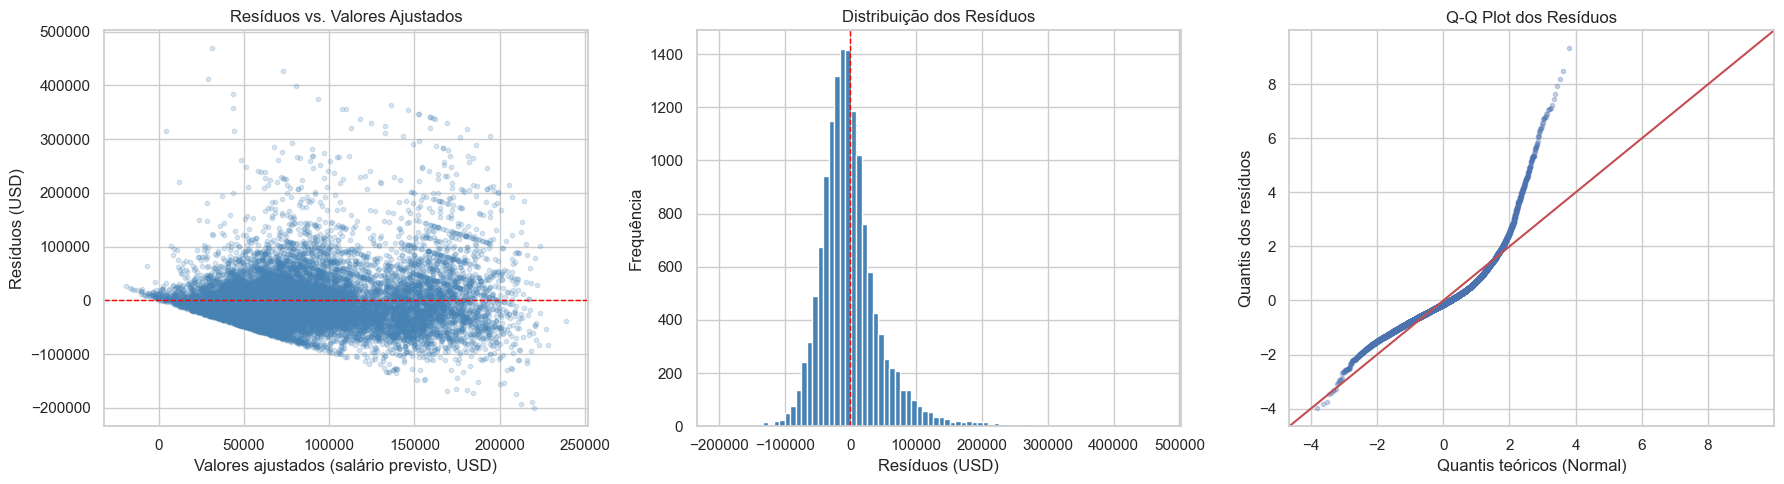

Figura salva em output/figures/04_analise_residuos.png


In [12]:
# Extração dos resíduos e dos valores ajustados.
# residuos[i] = salario_observado[i] - salario_previsto[i]
residuos = modelo.resid
ajustados = modelo.fittedvalues

# Painel com três gráficos canônicos de análise de resíduos.
# Cada subplot diagnostica um pressuposto diferente:
#   Esquerda  - resíduos vs ajustados  -> linearidade e homocedasticidade
#   Centro    - histograma dos resíduos -> normalidade (visão geral)
#   Direita   - Q-Q plot                -> normalidade (visão fina nas caudas)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: resíduos vs valores ajustados
axes[0].scatter(ajustados, residuos, alpha=0.2, s=10, color="steelblue")
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Valores ajustados (salário previsto, USD)")
axes[0].set_ylabel("Resíduos (USD)")
axes[0].set_title("Resíduos vs. Valores Ajustados")

# Gráfico 2: histograma dos resíduos
axes[1].hist(residuos, bins=80, color="steelblue", edgecolor="white")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Resíduos (USD)")
axes[1].set_ylabel("Frequência")
axes[1].set_title("Distribuição dos Resíduos")

# Gráfico 3: Q-Q plot
sm.qqplot(residuos, line="45", fit=True, ax=axes[2], markersize=3, alpha=0.3)
axes[2].set_title("Q-Q Plot dos Resíduos")
axes[2].set_xlabel("Quantis teóricos (Normal)")
axes[2].set_ylabel("Quantis dos resíduos")

plt.tight_layout()
plt.savefig(
    "../output/figures/04_analise_residuos.png",
    dpi=120, bbox_inches="tight",
)
plt.show()
print("Figura salva em output/figures/04_analise_residuos.png")

In [17]:
# Testes formais de normalidade dos resíduos.
# Combinam-se Jarque-Bera (já presente no summary) e Shapiro-Wilk.
#
# Atenção: em amostras muito grandes (n = 14.171), testes de normalidade
# tendem a rejeitar a hipótese nula mesmo para desvios pequenos. A
# inspeção visual do Q-Q plot é tão importante quanto o p-valor formal.

# Jarque-Bera (recalculado para registro explícito; já consta do summary)
jb_stat, jb_pvalue = stats.jarque_bera(residuos)

# Shapiro-Wilk
# scipy aceita até 5.000 observações por chamada; com n = 14.171, sorteamos
# uma subamostra reproduzível para o teste. Isso é prática padrão e está
# documentado na própria documentação do scipy.
rng = np.random.default_rng(seed=42)
amostra_sw = rng.choice(residuos, size=5000, replace=False)
sw_stat, sw_pvalue = stats.shapiro(amostra_sw)

# Estatísticas descritivas dos resíduos para complementar
testes_normalidade = pd.DataFrame([
    {"Teste": "Jarque-Bera",            "Estatística": f"{jb_stat:,.2f}",  "p-valor": f"{jb_pvalue:.2e}"},
    {"Teste": "Shapiro-Wilk (n=5.000)", "Estatística": f"{sw_stat:.4f}",   "p-valor": f"{sw_pvalue:.2e}"},
    {"Teste": "Assimetria (skew)",      "Estatística": f"{stats.skew(residuos):.4f}",     "p-valor": "—"},
    {"Teste": "Curtose (excesso)",      "Estatística": f"{stats.kurtosis(residuos):.4f}", "p-valor": "—"},
])

testes_normalidade.to_csv(
    "../output/tables/04_testes_normalidade_residuos.csv",
    index=False,
)
print("Tabela salva em output/tables/04_testes_normalidade_residuos.csv")
testes_normalidade

Tabela salva em output/tables/04_testes_normalidade_residuos.csv


,Teste,Estatística,p-valor
0,Jarque-Bera,"54,435.12",0.00e+00
1,Shapiro-Wilk (n=5.000),0.8574,2.28e-55
2,Assimetria (skew),1.9470,—
3,Curtose (excesso),8.7766,—


### 7.1 Leitura dos diagnósticos e implicações

**Resíduos vs. valores ajustados.** A nuvem apresenta dispersão crescente
ao longo dos valores ajustados resíduos pequenos para salários previstos
baixos e dispersão muito maior para salários previstos altos. Esse padrão
em forma de cone é o sinal clássico de heterocedasticidade: a variância
dos erros não é constante. É um achado esperado em dados de salário, em
que a faixa de remuneração se amplia conforme o salário esperado aumenta
(há mais variação possível em salários altos do que em baixos).

**Histograma dos resíduos.** A distribuição é centrada perto de zero,
mas claramente assimétrica à direita e com caudas pesadas. A massa de
probabilidade no centro é maior do que a normal preveria, e existem
resíduos extremos positivos (desenvolvedores ganhando muito mais do que
o modelo prevê) que destoam da forma de sino esperada.

**Q-Q plot.** Os pontos seguem a reta diagonal na região central, mas se
afastam pronunciadamente nas caudas em particular na cauda direita,
onde os resíduos observados são muito maiores do que a normal preveria.
Esse desvio confirma a curtose elevada (11,78 contra 3 da normal).

**Testes formais.** Tanto Jarque-Bera quanto Shapiro-Wilk rejeitam
normalidade com p < 0,001. Em uma amostra de 14.171 observações, esses
testes têm poder estatístico altíssimo e detectam mesmo desvios
pequenos da normal por isso, em amostras grandes, o Q-Q plot é o
diagnóstico mais informativo na prática.

**Implicações para a validade do modelo.** Os coeficientes estimados
permanecem **não enviesados** mesmo com violação de normalidade e
homocedasticidade o teorema de Gauss-Markov garante isso desde que
os resíduos tenham média zero e sejam não-correlacionados com X. O que
fica comprometido são os **erros padrão e p-valores**, que pressupõem
homocedasticidade. Em amostras grandes (n = 14.171), o teorema central
do limite atenua essa preocupação: a distribuição amostral dos
coeficientes converge para a normal independentemente da distribuição
dos resíduos, tornando os testes de hipótese aproximadamente válidos.

**Caminho de robustez.** A solução padrão para heterocedasticidade é o
uso de erros padrão robustos (HC0/HC3, White), que ajustam os erros
padrão sem alterar os coeficientes. A não-normalidade pronunciada
sugere também que uma transformação logarítmica do salário (log_salario,
já presente no dataset) seria um modelo de robustez natural. Essas
extensões não fazem parte dos itens obrigatórios da disciplina, mas
ficam registradas como caminhos válidos para uma análise estendida.

## 8. Diagnóstico de multicolinearidade

A análise exploratória do notebook 03 identificou pares de linguagens
com correlação moderada a alta JavaScript com HTML/CSS (0,57), C com
C++ (0,54), JavaScript com TypeScript (0,42), C# com PowerShell (0,35)
e Java com Kotlin (0,31). Quando variáveis explicativas estão fortemente
correlacionadas entre si, o modelo tem dificuldade de isolar o efeito
individual de cada uma: os coeficientes ficam instáveis, os erros
padrão inflam e os p-valores podem subestimar a relevância das
variáveis.

O Variance Inflation Factor (VIF) é a métrica padrão para diagnosticar
esse problema. Para cada variável explicativa, o VIF mede o quanto a
variância do seu coeficiente está inflada pela presença das demais. As
faixas usuais de interpretação são:

- VIF entre 1 e 5: correlação aceitável, sem necessidade de ação
- VIF entre 5 e 10: zona de atenção
- VIF acima de 10: multicolinearidade severa, possivelmente comprometendo a estimação

O número de condição reportado no summary do modelo (317) já indica
multicolinearidade moderada. O VIF permite localizar exatamente em
quais variáveis ela se concentra.

In [14]:
# Cálculo do VIF para cada variável explicativa.
#
# O VIF do intercepto não é informativo (sempre alto por construção)
# e por isso é removido antes do cálculo.

X_sem_const = X.drop(columns=["const"])

vif_dados = pd.DataFrame({
    "Variável": X_sem_const.columns,
    "VIF": [
        variance_inflation_factor(X_sem_const.values, i)
        for i in range(X_sem_const.shape[1])
    ],
})

# Classificação por faixa para leitura rápida
def classifica_vif(v):
    if v < 5:   return "OK"
    if v < 10:  return "Atenção"
    return "Severo"

vif_dados["Faixa"] = vif_dados["VIF"].apply(classifica_vif)
vif_dados = vif_dados.sort_values("VIF", ascending=False).reset_index(drop=True)

# Persiste em CSV
vif_dados.to_csv("../output/tables/04_vif_modelo_global.csv", index=False)
print("Tabela salva em output/tables/04_vif_modelo_global.csv")
print()
print(f"VIF máximo:  {vif_dados['VIF'].max():.2f}")
print(f"VIF mediano: {vif_dados['VIF'].median():.2f}")
print(f"Variáveis com VIF >= 5:  {(vif_dados['VIF'] >= 5).sum()}")
print(f"Variáveis com VIF >= 10: {(vif_dados['VIF'] >= 10).sum()}")
print()
vif_dados

Tabela salva em output/tables/04_vif_modelo_global.csv

VIF máximo:  5.59
VIF mediano: 1.35
Variáveis com VIF >= 5:  1
Variáveis com VIF >= 10: 0



,Variável,VIF,Faixa
0,lang_JavaScript,5.5948,Atenção
1,lang_HTML_CSS,4.7598,OK
2,YearsCode,3.3659,OK
3,lang_SQL,3.2433,OK
4,dev_fullstack,2.8533,OK
5,lang_TypeScript,2.7968,OK
6,lang_Python,2.4140,OK
7,pais_Outros,2.2731,OK
8,lang_Bash_Shell,2.2192,OK
9,lang_CPlusPlus,1.8384,OK


### 8.1 Resultado do diagnóstico

O VIF máximo observado foi 5,59 (JavaScript), com mediana de 1,35.
Nenhuma variável apresentou VIF acima de 10, valor a partir do qual a
literatura considera multicolinearidade severa. Apenas uma variável
ficou na faixa de atenção (5 ≤ VIF < 10), e o número de variáveis com
VIF abaixo de 5 limite usual de aceitação é de 40 entre 41.

A interpretação dos coeficientes do modelo é, portanto, considerada
estável: as correlações entre linguagens identificadas na análise
exploratória não foram fortes o suficiente para comprometer a
estimação dos efeitos marginais individuais. Nenhuma ação corretiva
(remoção ou agrupamento de variáveis) é necessária.

## 9. Análise de variância (ANOVA)

A tabela ANOVA decompõe a variação total do salário em duas parcelas:
a explicada pelo modelo (regressão) e a não explicada (resíduos).
A estatística F resultante testa a significância conjunta de todas as
variáveis explicativas. A hipótese nula é que todos os coeficientes
(exceto o intercepto) seriam simultaneamente iguais a zero, ou seja,
que o modelo não explica nada.

In [15]:
# Construção manual da tabela ANOVA do modelo global.
# Os componentes são extraídos diretamente do objeto modelo.

ss_regressao = modelo.ess          # Soma de quadrados explicada
ss_residuos  = modelo.ssr          # Soma de quadrados dos resíduos
ss_total     = ss_regressao + ss_residuos

gl_regressao = int(modelo.df_model)
gl_residuos  = int(modelo.df_resid)
gl_total     = gl_regressao + gl_residuos

ms_regressao = ss_regressao / gl_regressao
ms_residuos  = ss_residuos / gl_residuos

f_stat   = modelo.fvalue
p_valor  = modelo.f_pvalue

anova = pd.DataFrame([
    {
        "Fonte": "Regressão",
        "Soma de Quadrados": f"{ss_regressao:,.2f}",
        "GL": gl_regressao,
        "Quadrado Médio": f"{ms_regressao:,.2f}",
        "F": f"{f_stat:,.2f}",
        "p-valor": f"{p_valor:.2e}",
    },
    {
        "Fonte": "Resíduos",
        "Soma de Quadrados": f"{ss_residuos:,.2f}",
        "GL": gl_residuos,
        "Quadrado Médio": f"{ms_residuos:,.2f}",
        "F": "—",
        "p-valor": "—",
    },
    {
        "Fonte": "Total",
        "Soma de Quadrados": f"{ss_total:,.2f}",
        "GL": gl_total,
        "Quadrado Médio": "—",
        "F": "—",
        "p-valor": "—",
    },
])

anova.to_csv("../output/tables/04_anova_modelo_global.csv", index=False)
print("Tabela salva em output/tables/04_anova_modelo_global.csv")
anova

Tabela salva em output/tables/04_anova_modelo_global.csv


,Fonte,Soma de Quadrados,GL,Quadrado Médio,F,p-valor
0,Regressão,"28,885,729,190,006.16",41,"704,529,980,244.05",278.06,0.00e+00
1,Resíduos,"35,798,987,963,318.88",14129,"2,533,724,110.93",—,—
2,Total,"64,684,717,153,325.05",14170,—,—,—


### 9.1 Leitura

A estatística F = 278,06 com p-valor < 0,001 rejeita a hipótese nula
de que todos os coeficientes do modelo seriam conjuntamente iguais a
zero. Em termos práticos: o conjunto de variáveis explicativas
(linguagens, experiência, país, área e formação) é estatisticamente
relevante para explicar a variação salarial. O modelo, como um todo,
é válido.

## 10. Previsões

Para ilustrar a aplicação prática do modelo, três cenários hipotéticos
são apresentados. Cada cenário define um perfil profissional completo
e o modelo retorna a previsão de salário anual em USD junto com o
intervalo de confiança de 95%.

In [16]:
# Construção de três cenários de previsão.
# Cada cenário é um vetor com os mesmos nomes de coluna de X.
# Variáveis omitidas (não setadas explicitamente) ficam em zero,
# o que corresponde à categoria de referência (USA, backend, Bacharelado).

def montar_cenario(years_code, linguagens=None, pais=None, dev=None, edlevel=None):
    """Cria uma linha com as colunas de X, preenchida conforme o cenário."""
    cenario = pd.Series(0, index=X.columns, dtype=float)
    cenario["const"] = 1.0
    cenario["YearsCode"] = years_code
    for lang in (linguagens or []):
        cenario[f"lang_{lang}"] = 1
    if pais:    cenario[f"pais_{pais}"] = 1
    if dev:     cenario[f"dev_{dev}"] = 1
    if edlevel: cenario[f"ed_{edlevel}"] = 1
    return cenario

# Cenário 1: dev brasileiro fullstack pleno, stack web moderna
c1 = montar_cenario(
    years_code=8,
    linguagens=["JavaScript", "TypeScript", "Python", "SQL"],
    pais="Brazil",
    dev="fullstack",
    edlevel=None,  # Bacharelado é referência
)

# Cenário 2: dev americano backend sênior com Go e Rust
c2 = montar_cenario(
    years_code=15,
    linguagens=["Go", "Rust", "Python", "SQL"],
    pais=None,  # USA é referência
    dev=None,   # backend é referência
    edlevel="Mestrado",
)

# Cenário 3: dev indiano mobile júnior
c3 = montar_cenario(
    years_code=3,
    linguagens=["Kotlin", "Java", "SQL"],
    pais="India",
    dev="mobile",
    edlevel=None,  # Bacharelado é referência
)

cenarios = pd.DataFrame([c1, c2, c3])
cenarios.index = [
    "Brasil • fullstack • 8 anos • JS/TS/Python/SQL",
    "EUA • backend • 15 anos • Go/Rust/Python/SQL • Mestrado",
    "Índia • mobile • 3 anos • Kotlin/Java/SQL",
]

# Previsões com intervalo de confiança 95%
previsoes = modelo.get_prediction(cenarios).summary_frame(alpha=0.05)

resultado_previsoes = pd.DataFrame({
    "Cenário": cenarios.index,
    "Salário previsto (USD)": previsoes["mean"].values,
    "IC 95% inferior": previsoes["mean_ci_lower"].values,
    "IC 95% superior": previsoes["mean_ci_upper"].values,
})

# Formatação para apresentação
resultado_formatado = resultado_previsoes.copy()
for col in ["Salário previsto (USD)", "IC 95% inferior", "IC 95% superior"]:
    resultado_formatado[col] = resultado_formatado[col].apply(lambda x: f"{x:,.2f}")

resultado_formatado.to_csv(
    "../output/tables/04_previsoes_cenarios.csv",
    index=False,
)
print("Tabela salva em output/tables/04_previsoes_cenarios.csv")
resultado_formatado

Tabela salva em output/tables/04_previsoes_cenarios.csv


,Cenário,Salário previsto (USD),IC 95% inferior,IC 95% superior
0,Brasil • fullstack • 8 anos • JS/TS/Python/SQL,"35,596.30","29,614.29","41,578.31"
1,EUA • backend • 15 anos • Go/Rust/Python/SQL •...,"179,642.72","175,062.93","184,222.50"
2,Índia • mobile • 3 anos • Kotlin/Java/SQL,"20,373.48","13,831.26","26,915.71"


### 10.1 Leitura das previsões

As três previsões ilustram a sensibilidade do modelo aos principais controles. A diferença entre o cenário 2 (EUA, sênior, stack moderna) e o cenário 3 (Índia, júnior, stack mobile) reflete principalmente o efeito-país combinado ao efeito-experiência. O cenário 1 (Brasil, pleno) ocupa posição intermediária, com o efeito-país brasileiro (-USD 108.500) sendo parcialmente compensado pela stack moderna (TypeScript adiciona +USD 10.560) e pela experiência acumulada.

Os intervalos de confiança refletem a precisão da estimativa **da média condicional** para cada perfil não a faixa esperada de salários individuais. Para um indivíduo específico daquele perfil, o erro padrão da regressão (~USD 50.336) é o melhor indicador de incerteza.

## 11. Conclusões do modelo global

O modelo de regressão linear múltipla estimado responde à pergunta central da pesquisa associando linguagens de programação a níveis salariais controlando por experiência, país, área de atuação e formação acadêmica.

**Resultados principais:**

- Sete linguagens apresentaram prêmio salarial estatisticamente significativo: Ruby (+13.210), Go (+12.680), TypeScript (+10.560), Swift (+7.575), Rust (+6.713), Kotlin (+6.319) e Bash/Shell (+5.170).

- Sete linguagens apresentaram penalidade significativa: PHP (–13.940), Dart (–9.206), HTML/CSS (–7.214), CSharp (–6.568), C (–6.445), PowerShell (–3.926) e SQL (–3.492).

- Seis linguagens (C++, Groovy, Java, JavaScript, Lua e Python) não apresentaram efeito distinguível de zero ao nível de 5%.

- Cada ano adicional de experiência adiciona em média USD 1.558 ao salário esperado.

- País é o controle mais influente: em relação aos EUA, todos os países apresentam salários esperados significativamente menores, com Índia, Ucrânia e Brasil registrando as maiores penalidades.

**Validação do modelo:**

- R² de 0,447 indica que o conjunto de variáveis explica 44,7% da variação salarial, faixa consistente com a literatura de equação salarial em dados de survey.

- A estatística F (278,06; p < 0,001) e a tabela ANOVA confirmam a significância conjunta das variáveis explicativas.

- O diagnóstico de multicolinearidade via VIF (máximo 5,59) descarta problemas de instabilidade na estimação dos coeficientes.

- A análise de resíduos identificou heterocedasticidade e não-normalidade. Com n = 14.171, o teorema central do limite protege parcialmente os testes de hipótese, mas o ponto fica registrado como limite metodológico do modelo.

**Limitações:**

- Os coeficientes capturam **associações**, não relações causais. "Linguagem X paga mais" não significa "aprender X aumenta o salário" pode refletir que desenvolvedores que usam X já tendem a estar em contextos de remuneração superior.

- A amostra é autorrelatada e enviesada para usuários do Stack Overflow, o que limita a generalização para o universo total de desenvolvedores.

- Fatores não observados (qualidade da empresa, performance individual, capacidade de negociação) respondem por 55,3% da variação salarial e não são modelados.

A pergunta central da pesquisa fica respondida: linguagens **estão associadas** a diferenciais salariais relevantes, mesmo após controlar por experiência, país, área e formação. As análises segmentadas (notebook 05) refinarão essa resposta, examinando se as associações persistem ou se alteram em subamostras por área de atuação, recorte geográfico e nível de experiência.